In [5]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "../data/raw/marketing_history.xlsx"

df = pd.read_excel(file_path, header=2)

print("Размер таблицы:", df.shape)
df.head()

Размер таблицы: (210, 35)


,event_id,event_time,source_channel,activity_type,course,campaign,placement,creative_text,external_or_internal,post_url,...,raw_promo_candidate,raw_offer_flag,raw_discount_flag,raw_launch_flag,raw_lead_magnet_flag,raw_ad_marking,raw_erid,raw_scraped_at,raw_html_ref,Unnamed: 34
0,INT-1764,2026-07-01 18:10:49,@postypashki_old,Контент с предложением курсов (авто),ML старт | Data Science,NaN,postypashki_old/1764,Самые интересные события в ближайшее время.\nВ...,internal,https://t.me/postypashki_old/1764,...,NaN,1.0,0.0,0.0,0.0,NaN,False,2026-07-01T15:10:49+00:00,NaN,NaN
1,INT-1765,2026-07-02 18:31:22,@postypashki_old,Прочий контент (авто),NaN,NaN,postypashki_old/1765,"В новом ролике обсудим, что с вашей психикой с...",internal,https://t.me/postypashki_old/1765,...,NaN,0.0,0.0,0.0,0.0,NaN,False,2026-07-02T15:31:22+00:00,NaN,NaN
2,INT-1767,2026-07-04 12:03:55,@postypashki_old,Промо со скидкой (авто),NaN,NaN,postypashki_old/1767,❗️ Завтра заканчивается донабор на стажировку ...,internal,https://t.me/postypashki_old/1767,...,NaN,1.0,1.0,0.0,0.0,NaN,False,2026-07-04T09:03:55+00:00,NaN,NaN
3,INT-1768,2026-07-04 15:35:53,@postypashki_old,Контент с предложением курсов (авто),ML старт,NaN,postypashki_old/1768,Академия Авито и Буткем Авито \n\nСегодня прош...,internal,https://t.me/postypashki_old/1768,...,NaN,1.0,0.0,0.0,0.0,NaN,False,2026-07-04T12:35:53+00:00,NaN,NaN
4,INT-1770,2026-07-05 16:51:14,@postypashki_old,Прочий контент (авто),ML старт,NaN,postypashki_old/1770,Как затащить МЛ собеседование в 2026 году \n\n...,internal,https://t.me/postypashki_old/1770,...,NaN,0.0,1.0,0.0,0.0,NaN,False,2026-07-05T13:51:14+00:00,NaN,NaN


In [6]:
df.columns.tolist()

['event_id',
 'event_time',
 'source_channel',
 'activity_type',
 'course',
 'campaign',
 'placement',
 'creative_text',
 'external_or_internal',
 'post_url',
 'views',
 'reactions',
 'cost_rub',
 'data_source',
 'confidence',
 'collected_by',
 'notes',
 'channel_relationship',
 'paid_status',
 'raw_origin',
 'raw_category',
 'raw_period',
 'raw_media',
 'raw_forwarded_from',
 'raw_links',
 'raw_promo_candidate',
 'raw_offer_flag',
 'raw_discount_flag',
 'raw_launch_flag',
 'raw_lead_magnet_flag',
 'raw_ad_marking',
 'raw_erid',
 'raw_scraped_at',
 'raw_html_ref',
 'Unnamed: 34']

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   event_id              210 non-null    str    
 1   event_time            210 non-null    str    
 2   source_channel        210 non-null    str    
 3   activity_type         210 non-null    str    
 4   course                35 non-null     str    
 5   campaign              0 non-null      float64
 6   placement             210 non-null    str    
 7   creative_text         193 non-null    str    
 8   external_or_internal  210 non-null    str    
 9   post_url              210 non-null    str    
 10  views                 210 non-null    int64  
 11  reactions             189 non-null    float64
 12  cost_rub              0 non-null      float64
 13  data_source           210 non-null    str    
 14  confidence            210 non-null    str    
 15  collected_by          210 non-null

In [8]:
missing = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .round(1)
)

missing

cost_rub                100.0
campaign                100.0
raw_ad_marking           98.6
course                   83.3
raw_media                77.6
raw_forwarded_from       76.7
raw_launch_flag          53.8
raw_offer_flag           53.8
raw_discount_flag        53.8
raw_period               53.8
raw_lead_magnet_flag     53.8
raw_scraped_at           53.8
raw_promo_candidate      46.2
raw_links                46.2
raw_html_ref             46.2
Unnamed: 34              46.2
reactions                10.0
creative_text             8.1
raw_category              0.0
raw_erid                  0.0
event_id                  0.0
raw_origin                0.0
paid_status               0.0
event_time                0.0
notes                     0.0
collected_by              0.0
confidence                0.0
data_source               0.0
views                     0.0
post_url                  0.0
external_or_internal      0.0
placement                 0.0
activity_type             0.0
source_cha

In [10]:
df["external_or_internal"].value_counts(dropna=False)

external_or_internal
external    113
internal     97
Name: count, dtype: int64

In [11]:
df["activity_type"].value_counts()

activity_type
Продвижение курсов / промо (кандидат по тексту)    80
Контент с предложением курсов (авто)               36
Прочий контент (авто)                              23
Бесплатное событие / лид-магнит                    12
Контент со ссылкой / упоминанием                   12
Медиа без текста / нужна проверка                  11
Бесплатное событие / лид-магнит (авто)             10
Пересылка / контентное упоминание                   9
Рекламная маркировка / проверить направление        8
Промо со скидкой (авто)                             6
Запуск / набор (авто)                               3
Name: count, dtype: int64

In [12]:
channel_counts = df["source_channel"].value_counts()

channel_counts

source_channel
@postypashki_old     97
@chad_protocol       21
@ProdAnalysis        20
@zadachi_ds          19
@codeof_art          16
@postypashki_mems    16
@algoses             12
@matesha_shad         9
Name: count, dtype: int64

In [13]:
channel_summary = (
    df.groupby(["external_or_internal", "source_channel"])
      .size()
      .reset_index(name="events_count")
      .sort_values("events_count", ascending=False)
)

channel_summary

,external_or_internal,source_channel,events_count
7,internal,@postypashki_old,97
2,external,@chad_protocol,21
0,external,@ProdAnalysis,20
6,external,@zadachi_ds,19
3,external,@codeof_art,16
5,external,@postypashki_mems,16
1,external,@algoses,12
4,external,@matesha_shad,9


In [14]:
type_by_source = pd.crosstab(
    df["activity_type"],
    df["external_or_internal"]
)

type_by_source

external_or_internal,external,internal
activity_type,,
Бесплатное событие / лид-магнит,12,0
Бесплатное событие / лид-магнит (авто),0,10
Запуск / набор (авто),0,3
Контент с предложением курсов (авто),0,36
Контент со ссылкой / упоминанием,12,0
Медиа без текста / нужна проверка,0,11
Пересылка / контентное упоминание,9,0
Продвижение курсов / промо (кандидат по тексту),80,0
Промо со скидкой (авто),0,6


## Типы маркетинговых событий

Внутренние и внешние события классифицированы по-разному.

Для собственного канала выделяются более конкретные типы:
продающий контент, скидки, запуски, лид-магниты, рекламная маркировка и др.

Для внешних источников классификация более укрупнённая:
промо-кандидаты, упоминания, пересылки и лид-магниты.

Поэтому количество событий разных типов нельзя напрямую интерпретировать
как интенсивность конкретного вида рекламы без дополнительной разметки.

In [15]:
fields = [
    "event_time",
    "source_channel",
    "activity_type",
    "course",
    "campaign",
    "creative_text",
    "views",
    "reactions",
    "cost_rub",
    "paid_status",
    "channel_relationship",
    "confidence"
]

fields = [col for col in fields if col in df.columns]

completeness = pd.DataFrame({
    "filled": df[fields].notna().sum(),
    "missing": df[fields].isna().sum()
})

completeness["filled_pct"] = (
    completeness["filled"] / len(df) * 100
).round(1)

completeness.sort_values("filled_pct")

,filled,missing,filled_pct
campaign,0,210,0.0
cost_rub,0,210,0.0
course,35,175,16.7
reactions,189,21,90.0
creative_text,193,17,91.9
event_time,210,0,100.0
source_channel,210,0,100.0
activity_type,210,0,100.0
views,210,0,100.0
paid_status,210,0,100.0


In [16]:
df["event_time"] = pd.to_datetime(df["event_time"])

df["date"] = df["event_time"].dt.date

In [17]:
events_daily = (
    df.groupby("date")
      .size()
      .reset_index(name="events")
)

events_daily.sort_values("events", ascending=False).head(15)

,date,events
38,2026-08-10,22
63,2026-09-07,13
49,2026-08-23,10
62,2026-09-06,8
36,2026-08-08,6
60,2026-09-03,6
26,2026-07-29,5
22,2026-07-25,5
15,2026-07-18,5
59,2026-09-02,5


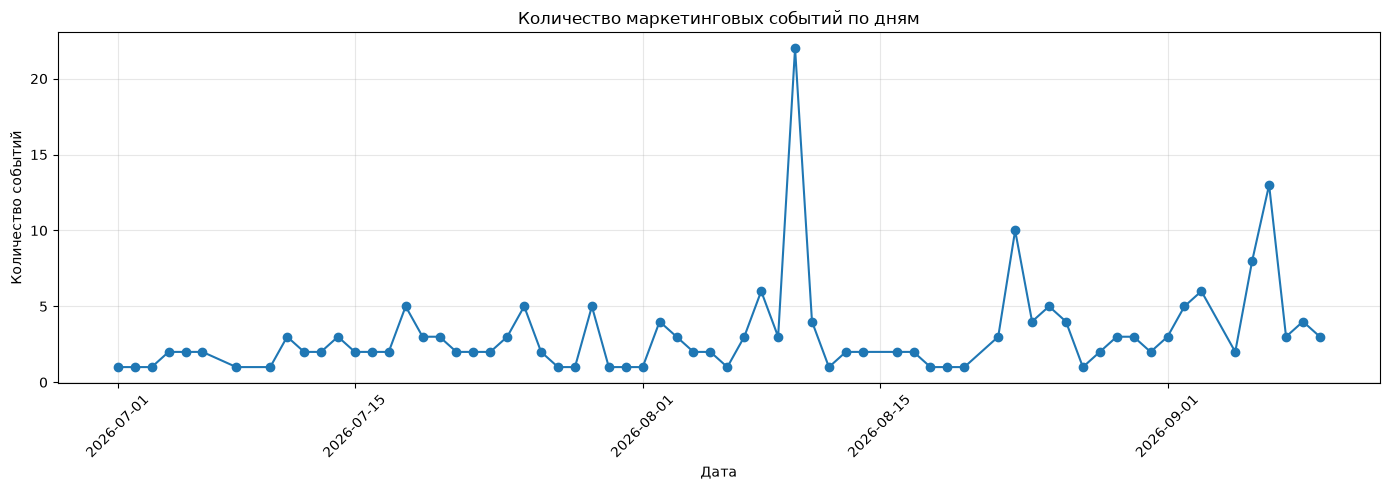

In [18]:
plt.figure(figsize=(14, 5))

plt.plot(
    pd.to_datetime(events_daily["date"]),
    events_daily["events"],
    marker="o"
)

plt.title("Количество маркетинговых событий по дням")
plt.xlabel("Дата")
plt.ylabel("Количество событий")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
top_events = (
    df.sort_values("views", ascending=False)
      [["event_time", "source_channel", "activity_type", "course", "views"]]
      .head(15)
)

top_events

,event_time,source_channel,activity_type,course,views
67,2026-08-22 13:19:48,@postypashki_old,Запуск / набор (авто),ML про | Backend про | Алгоритмы про | Аналити...,35200
40,2026-08-02 11:51:49,@postypashki_old,Бесплатное событие / лид-магнит (авто),NaN,32400
52,2026-08-10 20:33:06,@postypashki_old,Медиа без текста / нужна проверка,NaN,31600
51,2026-08-10 20:33:06,@postypashki_old,Промо со скидкой (авто),NaN,30500
17,2026-07-14 19:02:39,@postypashki_old,Бесплатное событие / лид-магнит (авто),Алгоритмы,26100
65,2026-08-19 18:58:14,@postypashki_old,Контент с предложением курсов (авто),NaN,23800
60,2026-08-16 12:20:46,@postypashki_old,Прочий контент (авто),NaN,23100
66,2026-08-20 19:11:50,@postypashki_old,Контент с предложением курсов (авто),NaN,22800
34,2026-07-27 20:05:25,@postypashki_old,Контент с предложением курсов (авто),Data Science,22700
21,2026-07-16 19:21:54,@postypashki_old,Прочий контент (авто),NaN,22600


In [21]:
promo_events = df[
    df["activity_type"]
      .astype(str)
      .str.contains("скид|запуск|набор", case=False, na=False)
].sort_values("event_time")

promo_events[
    ["event_time", "activity_type", "course", "source_channel", "views"]
]

,event_time,activity_type,course,source_channel,views
2,2026-07-04 12:03:55,Промо со скидкой (авто),NaN,@postypashki_old,18600
13,2026-07-12 16:49:28,Промо со скидкой (авто),Backend старт,@postypashki_old,17200
47,2026-08-09 13:32:11,Промо со скидкой (авто),AI агенты,@postypashki_old,18200
49,2026-08-10 16:26:59,Промо со скидкой (авто),Аналитика старт,@postypashki_old,16400
51,2026-08-10 20:33:06,Промо со скидкой (авто),NaN,@postypashki_old,30500
67,2026-08-22 13:19:48,Запуск / набор (авто),ML про | Backend про | Алгоритмы про | Аналити...,@postypashki_old,35200
68,2026-08-23 11:51:41,Промо со скидкой (авто),AI агенты | Data Engenering | АВ тестам,@postypashki_old,20400
78,2026-08-29 21:58:58,Запуск / набор (авто),ML про | Backend про | Алгоритмы про | Аналити...,@postypashki_old,20100
89,2026-09-07 13:47:40,Запуск / набор (авто),NaN,@postypashki_old,16700


In [22]:
channel_summary

,external_or_internal,source_channel,events_count
7,internal,@postypashki_old,97
2,external,@chad_protocol,21
0,external,@ProdAnalysis,20
6,external,@zadachi_ds,19
3,external,@codeof_art,16
5,external,@postypashki_mems,16
1,external,@algoses,12
4,external,@matesha_shad,9


In [23]:
completeness.sort_values("filled_pct")

,filled,missing,filled_pct
campaign,0,210,0.0
cost_rub,0,210,0.0
course,35,175,16.7
reactions,189,21,90.0
creative_text,193,17,91.9
event_time,210,0,100.0
source_channel,210,0,100.0
activity_type,210,0,100.0
views,210,0,100.0
paid_status,210,0,100.0


In [24]:
events_daily.sort_values("events", ascending=False).head(15)

,date,events
38,2026-08-10,22
63,2026-09-07,13
49,2026-08-23,10
62,2026-09-06,8
36,2026-08-08,6
60,2026-09-03,6
26,2026-07-29,5
22,2026-07-25,5
15,2026-07-18,5
59,2026-09-02,5


NameError: name 'course' is not defined